Step 1: Data Preparation

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the dataset
file_path = 'Group03/Regression/UnivariateData/3.csv'
data = pd.read_csv(file_path)

# Assuming the dataset has one column of input data and one column of output data
X = data.iloc[:, 0].values  # Input (independent variable)
y = data.iloc[:, 1].values  # Output (dependent variable)

# Split the dataset into training and testing sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Reshape data for polynomial fitting
X_train = X_train[:, np.newaxis]
X_test = X_test[:, np.newaxis]

# Step 2: Save the training and testing data to new files
train_data = pd.DataFrame({'X_train': X_train.flatten(), 'y_train': y_train})
test_data = pd.DataFrame({'X_test': X_test.flatten(), 'y_test': y_test})

train_data.to_csv('Group03/Regression/UnivariateData/train_data.csv', index=False)
test_data.to_csv('Group03/Regression/UnivariateData/test_data.csv', index=False)

# Step 3: Read the files back for EDA
train_data = pd.read_csv('Group03/Regression/UnivariateData/train_data.csv')
test_data = pd.read_csv('Group03/Regression/UnivariateData/test_data.csv')


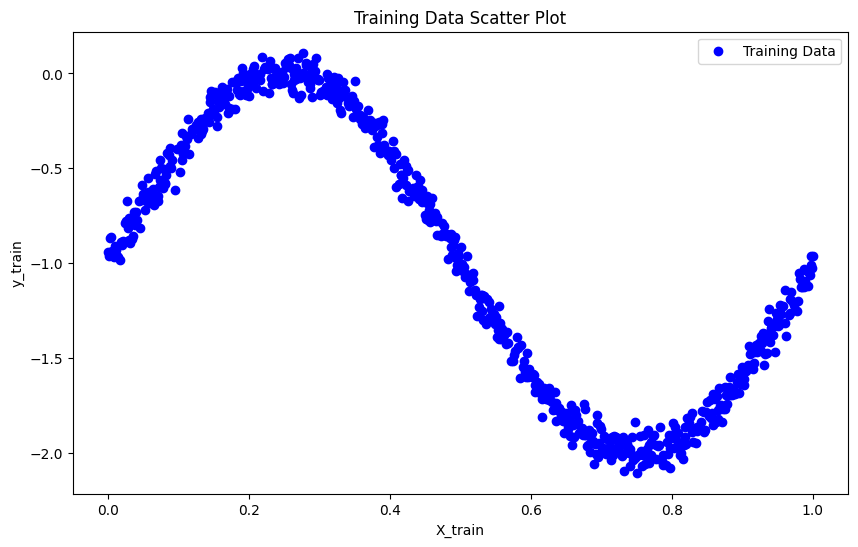

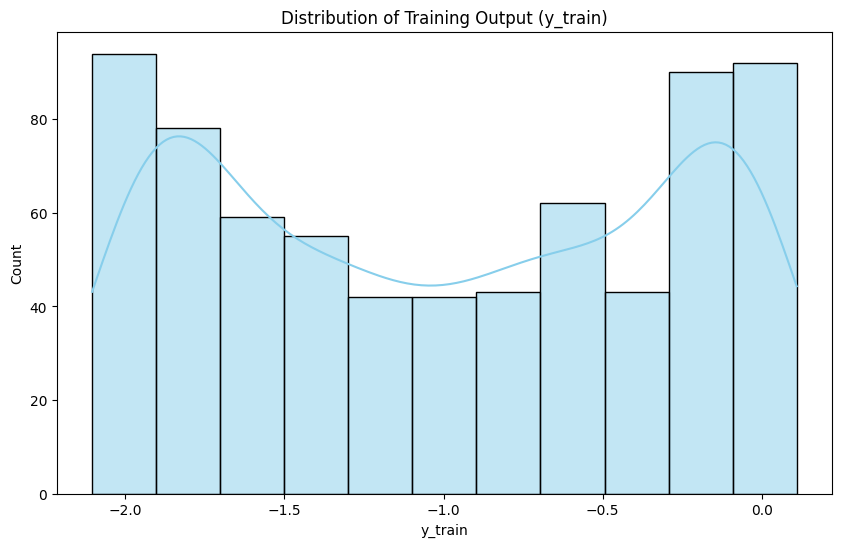

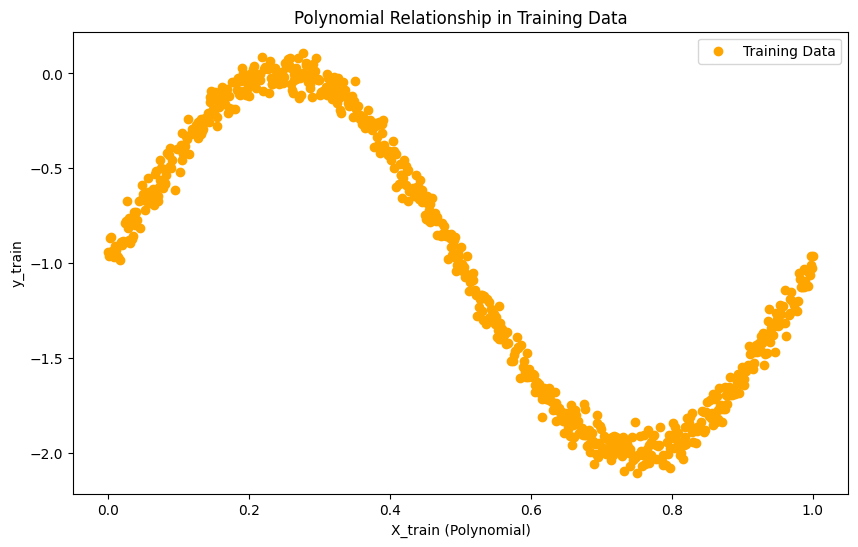

In [2]:

# Step 4: Perform EDA for Univariate Polynomial Regression

# Visualize the training data
plt.figure(figsize=(10, 6))
plt.scatter(train_data['X_train'], train_data['y_train'], color='blue', label='Training Data')
plt.xlabel('X_train')
plt.ylabel('y_train')
plt.title('Training Data Scatter Plot')
plt.legend()
plt.show()

# Distribution plot of training output
plt.figure(figsize=(10, 6))
sns.histplot(train_data['y_train'], kde=True, color='skyblue')
plt.xlabel('y_train')
plt.title('Distribution of Training Output (y_train)')
plt.show()

# Polynomial transformation of degree 2 for visualization
poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(train_data[['X_train']])

# Scatter plot for polynomial relationship
plt.figure(figsize=(10, 6))
plt.scatter(X_poly_train[:, 1], train_data['y_train'], color='orange', label='Training Data')
plt.xlabel('X_train (Polynomial)')
plt.ylabel('y_train')
plt.title('Polynomial Relationship in Training Data')
plt.legend()
plt.show()


### 1. Training Data Scatter Plot

   - **What It Represents**: The scatter plot displays the relationship between the independent variable \( X_{\text{train}} \) and the dependent variable \( y_{\text{train}} \) in the training dataset.
   - **How It Helps**: This initial visualization gives a clear view of the data distribution and any apparent relationship between \( X \) and \( y \). For polynomial regression, we're interested in seeing if the data might follow a curved pattern rather than a straight line, which would suggest a non-linear relationship.

### 2. Distribution of Training Output (Histogram with KDE)

   - **What It Represents**: This histogram, with a Kernel Density Estimation (KDE) overlay, shows the distribution of \( y_{\text{train}} \) values in the training dataset.
   - **How It Helps**: Understanding the output variable's distribution helps detect skewness or unusual spread, indicating possible outliers or non-normality. For polynomial regression, knowing the target's distribution helps to adjust model assumptions or preprocessing techniques if needed.

### 3. Polynomial Relationship in Training Data

   - **What It Represents**: This scatter plot uses a polynomial transformation (degree 2) on \( X_{\text{train}} \), capturing the potential curvilinear relationship with \( y_{\text{train}} \).
   - **How It Helps**: This plot reveals the effectiveness of a polynomial transformation by visually showing how well the transformed \( X \) relates to \( y \). If the points appear more aligned after transformation, it confirms that polynomial regression may effectively model this relationship. It helps in choosing the polynomial degree (e.g., quadratic, cubic) that best fits the data.

### Overall Importance for Univariate Polynomial Regression

These visualizations help to:
- **Detect Non-Linearity**: Assess if a linear model is insufficient and if polynomial regression is likely to capture data trends better.
- **Identify Data Patterns**: See if there’s a consistent pattern, e.g., quadratic or cubic, that suggests the best polynomial degree.
- **Prepare for Preprocessing**: Check for outliers, skewness, or unusual data points, which may require transformations or cleaning to improve model performance.
